# Tables

In [73]:
# List of time steps (The Set 'T')
hours = [
    "00:00", "01:00", "02:00", "03:00", "04:00", "05:00",
    "06:00", "07:00", "08:00", "09:00", "10:00", "11:00",
    "12:00", "13:00", "14:00", "15:00", "16:00", "17:00",
    "18:00", "19:00", "20:00", "21:00", "22:00", "23:00"
]

# Dictionary: Price of Power per kWh (Parameter 'P_t')
price_per_kwh = {
    "00:00": 0.05852, "01:00": 0.05082, "02:00": 0.04586, "03:00": 0.04307,
    "04:00": 0.03917, "05:00": 0.04340, "06:00": 0.06615, "07:00": 0.08520,
    "08:00": 0.08340, "09:00": 0.06498, "10:00": 0.04596, "11:00": 0.03162,
    "12:00": 0.01700, "13:00": 0.01190, "14:00": 0.01160, "15:00": 0.03041,
    "16:00": 0.04700, "17:00": 0.06368, "18:00": 0.08000, "19:00": 0.09510,
    "20:00": 0.08214, "21:00": 0.06140, "22:00": 0.05229, "23:00": 0.03630
}

# Dictionary: PV Yield in kWh (Parameter 'S_t')
pv_yield = {
    "00:00": 0, "01:00": 0, "02:00": 0, "03:00": 0,
    "04:00": 0, "05:00": 0, "06:00": 0, "07:00": 0,
    "08:00": 8, "09:00": 45, "10:00": 151, "11:00": 267,
    "12:00": 486, "13:00": 680, "14:00": 755, "15:00": 690,
    "16:00": 610, "17:00": 445, "18:00": 270, "19:00": 70,
    "20:00": 0, "21:00": 0, "22:00": 0, "23:00": 0
}

# Dictionary: Office Usage in kWh (Parameter 'D_t')
office_usage = {
    "00:00": 25, "01:00": 25, "02:00": 25, "03:00": 25,
    "04:00": 25, "05:00": 25, "06:00": 40, "07:00": 50,
    "08:00": 50, "09:00": 50, "10:00": 50, "11:00": 50,
    "12:00": 50, "13:00": 50, "14:00": 50, "15:00": 50,
    "16:00": 50, "17:00": 50, "18:00": 40, "19:00": 25,
    "20:00": 25, "21:00": 25, "22:00": 25, "23:00": 25
}

# Constants

In [74]:
# --- 1. Grid Connection Parameters ---
# Maximum capacity of the grid connection in kW
GRID_MAX_CAPACITY = 300

# --- 2. Electric Vehicle (EV) Parameters ---
# Total number of cars and battery capacity per car
NUM_CARS = 30
BATTERY_CAPACITY_PER_CAR = 100  # kWh
EV_TOTAL_DEMAND = NUM_CARS * BATTERY_CAPACITY_PER_CAR * 0.5  # Result: 1500 kWh
EV_MAX_CHARGING_POWER = 750  # kW

EV_CHARGING_WINDOW = [
    "06:00", "07:00", "08:00", "09:00", "10:00", "11:00", "12:00",
    "13:00", "14:00", "15:00", "16:00", "17:00", "18:00", "19:00"
]

# --- 3. Cold Storage (Cooling) Parameters ---
COOLING_BASE_LOAD = 200  # kWh per hour
COOLING_MAX_INPUT = 600  # kWh per hour
COOLING_MAX_STORAGE = 600  # kWh


In [75]:
import gurobipy as gp
from gurobipy import GRB

model = gp.Model("Energy Optimization")

#variables

grid_net = model.addVars(hours, lb=-GRID_MAX_CAPACITY,ub=GRID_MAX_CAPACITY, name="Grid")

# ev_charge: Charging power per hour.
ev_charge = model.addVars(hours, lb=0, ub=EV_MAX_CHARGING_POWER, name="EV_Charge")

# cooling_input: Power sent to the cooling system (0 to 600 kW)
cooling_input = model.addVars(hours, lb=0, ub=COOLING_MAX_INPUT, name="Cooling_Input")

# cooling_storage: The "cold buffer" available at the END of hour t
cooling_storage = model.addVars(hours, lb=0, ub=COOLING_MAX_STORAGE, name="Cooling_Storage")


obj_expr = gp.quicksum(grid_net[t] * price_per_kwh[t] for t in hours)


#constraints

for t in hours:
    model.addConstr(
        grid_net[t] == office_usage[t] + ev_charge[t] + cooling_input[t] - pv_yield[t],
        name=f"Balance_{t}"
    )

model.addConstr(gp.quicksum(ev_charge[t] for t in EV_CHARGING_WINDOW) >= EV_TOTAL_DEMAND, name="EV_Total_Requirement")

for t in hours:
    if t not in EV_CHARGING_WINDOW:
        model.addConstr(ev_charge[t] == 0, name=f"EV_Block_{t}")


previous_storage = 0 
for i, t in enumerate(hours):
    if i == 0:
        # First hour uses initial state (0)
        model.addConstr(cooling_storage[t] == previous_storage + cooling_input[t] - COOLING_BASE_LOAD, name=f"Cooling_Dyn_{t}")
    else:
        prev_t = hours[i-1]
        model.addConstr(cooling_storage[t] == cooling_storage[prev_t] + cooling_input[t] - COOLING_BASE_LOAD, name=f"Cooling_Dyn_{t}")



model.setObjective(obj_expr, GRB.MINIMIZE)

total_cost =0

model.optimize()
if model.status == GRB.OPTIMAL:
    # print("\n--- Optimal Schedule ---")
    # print(f"{'Hour':<6} | {'Price':<7} | {'PV':<5} | {'Office':<6} | {'EV':<5} | {'CoolIn':<6} | {'CoolStore':<9} | {'GridNet':<7}")
    # print("-" * 75)
    
    total_cost = model.ObjVal
    
    # for t in hours:
    #     # Get variable values
    #     ev_val = ev_charge[t].X
    #     cool_in_val = cooling_input[t].X
    #     cool_store_val = cooling_storage[t].X
    #     grid_val = grid_net[t].X
        
    #     print(f"{t:<6} | {price_per_kwh[t]:.4f}  | {pv_yield[t]:<5} | {office_usage[t]:<6} | {ev_val:>5.1f} | {cool_in_val:>6.1f} | {cool_store_val:>9.1f} | {grid_val:>7.1f}")

    print("-" * 75)
    print(f"Total Operational Cost: €{total_cost:.2f}")
else:
    print("No optimal solution found.")


Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i7-12850HX, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 59 rows, 96 columns and 167 nonzeros (Min)
Model fingerprint: 0x3c06e1b7
Model has 24 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-02, 1e-01]
  Bounds range     [3e+02, 8e+02]
  RHS range        [5e+00, 2e+03]
Presolve removed 21 rows and 21 columns
Presolve time: 0.01s
Presolved: 38 rows, 75 columns, 125 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -4.4809178e+01   9.667476e+02   0.000000e+00      0s
      28    1.0864085e+02   0.000000e+00   0.000000e+00      0s

Solved in 28 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.086408500e+02
---------------------------------------------------------------

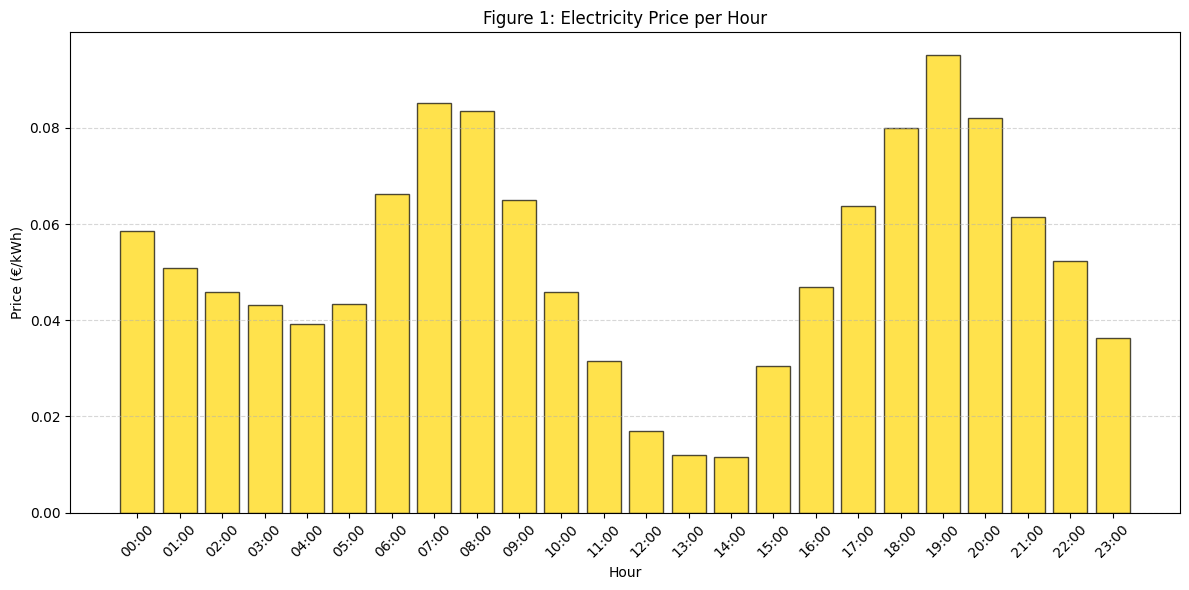

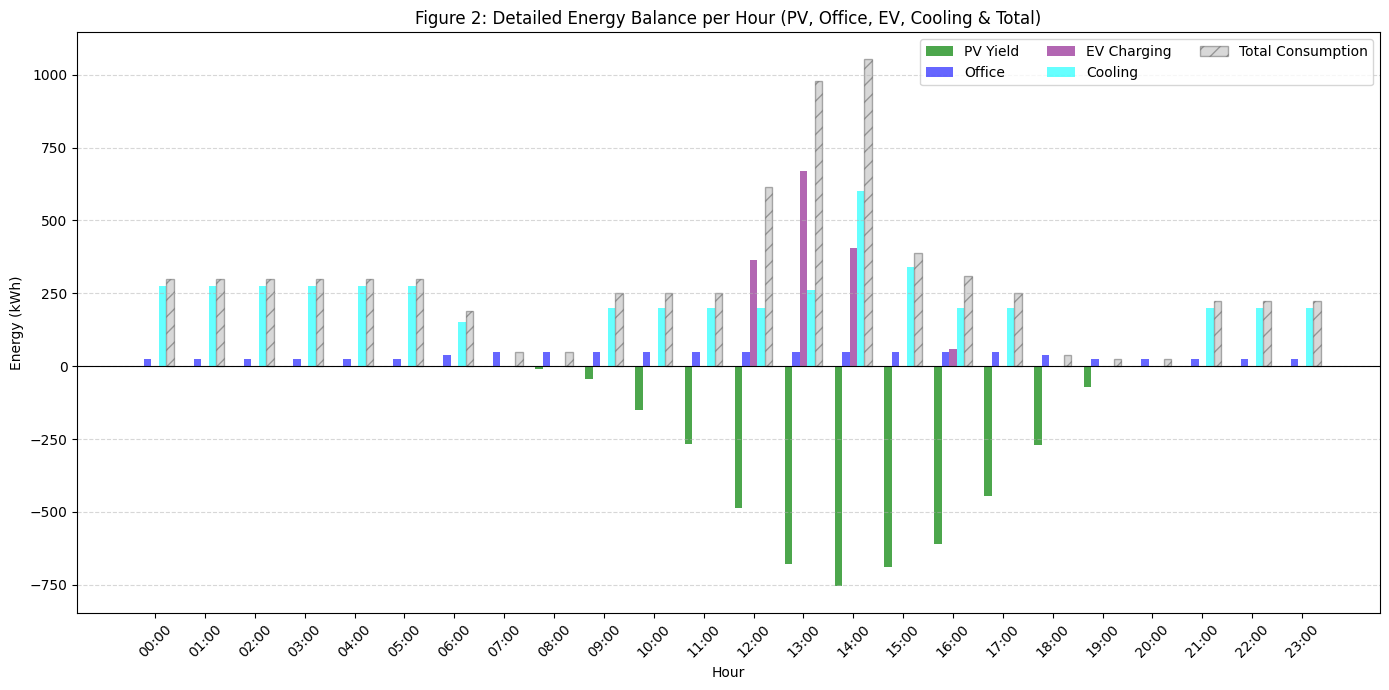

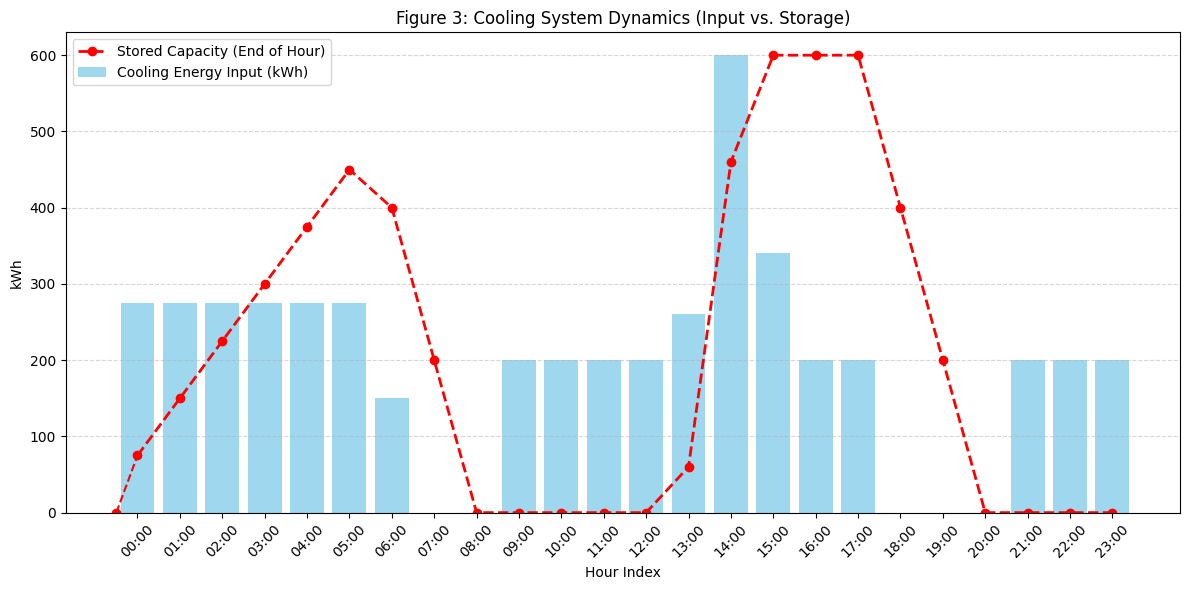

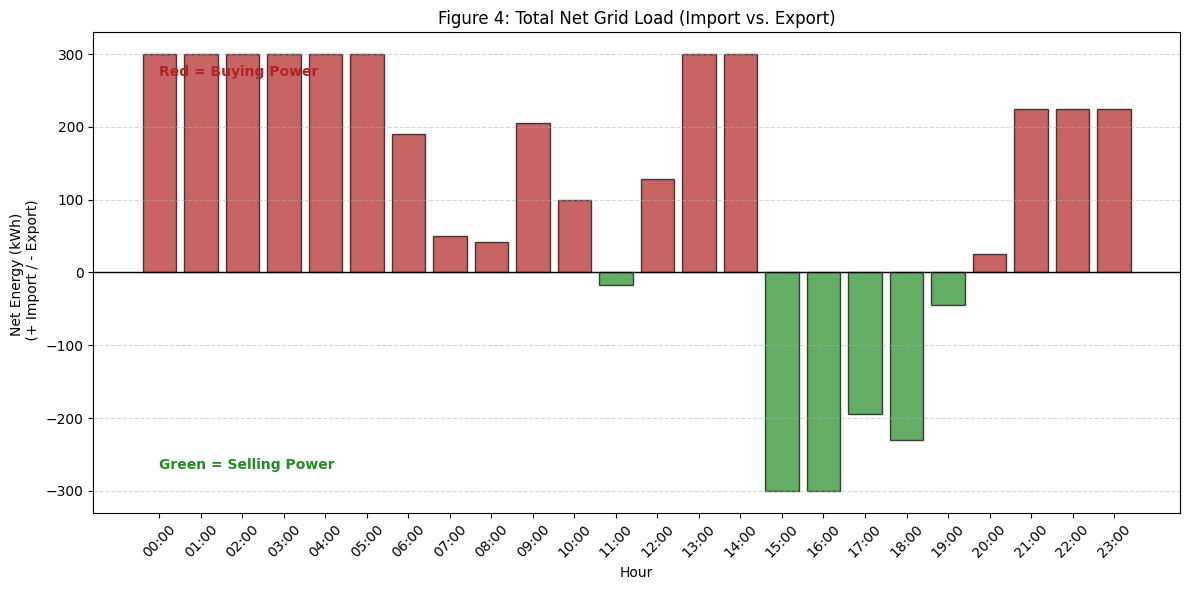

In [76]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np  # Needed for positioning the side-by-side bars

# --- 1. PREPARE DATA ---
# We calculate the lists first to easily compute the Total Load
pv_neg = [-pv_yield[t] for t in hours]
office = [office_usage[t] for t in hours]
cooling = [cooling_input[t].X for t in hours]
ev = [ev_charge[t].X for t in hours]
grid = [grid_net[t].X for t in hours]
price = [price_per_kwh[t] for t in hours]

# Calculate Total Consumption (Office + Cooling + EV)
total_load = [o + c + e for o, c, e in zip(office, cooling, ev)]

plot_data = {
    "Hour": hours,
    "Price": price,
    "PV_Yield_Neg": pv_neg,
    "Office_Usage": office,
    "Cooling_Input": cooling,
    "EV_Charge": ev,          # Added EV
    "Total_Load": total_load, # Added Total
    "Grid_Net": grid
}

# For the storage line logic
storage_values = [cooling_storage[t].X for t in hours]
storage_plot_values = [0] + storage_values 
storage_plot_time = [-0.5] + list(range(len(hours)))

df_plot = pd.DataFrame(plot_data)

# --- FIGURE 1: Prices per Hour ---
plt.figure(figsize=(12, 6))
plt.bar(df_plot["Hour"], df_plot["Price"], color='gold', edgecolor='black', alpha=0.7)
plt.title("Figure 1: Electricity Price per Hour")
plt.ylabel("Price (€/kWh)")
plt.xlabel("Hour")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- FIGURE 2: Detailed Energy Balance (Side-by-Side) ---
# UPDATED: Now includes EV and Total Load in a grouped bar chart
plt.figure(figsize=(14, 7))

# X-axis setup
x = np.arange(len(hours)) 
width = 0.15  # Width of the bars

# Plotting the bars side-by-side
# 1. PV Yield (Green, Negative)
plt.bar(x - 2*width, df_plot["PV_Yield_Neg"], width, label='PV Yield', color='green', alpha=0.7)
# 2. Office Usage (Blue)
plt.bar(x - 1*width, df_plot["Office_Usage"], width, label='Office', color='blue', alpha=0.6)
# 3. EV Charging (Purple)
plt.bar(x,           df_plot["EV_Charge"],    width, label='EV Charging', color='purple', alpha=0.6)
# 4. Cooling Usage (Cyan)
plt.bar(x + 1*width, df_plot["Cooling_Input"], width, label='Cooling', color='cyan', alpha=0.6)
# 5. Total Consumption (Gray, Hatched)
plt.bar(x + 2*width, df_plot["Total_Load"],    width, label='Total Consumption', color='gray', alpha=0.3, hatch='//', edgecolor='black')

plt.axhline(0, color='black', linewidth=0.8)
plt.title("Figure 2: Detailed Energy Balance per Hour (PV, Office, EV, Cooling & Total)")
plt.ylabel("Energy (kWh)")
plt.xlabel("Hour")
plt.xticks(x, hours, rotation=45)
plt.legend(loc="upper right", ncol=3) # Spread legend over 3 columns
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- FIGURE 3: Cooling Usage & Storage (With 0-Start Offset) ---
plt.figure(figsize=(12, 6))
plt.bar(df_plot["Hour"], df_plot["Cooling_Input"], color='skyblue', label='Cooling Energy Input (kWh)', alpha=0.8)

# Line chart for storage
plt.plot(storage_plot_time[1:], storage_values, color='red', linestyle='--', marker='o', linewidth=2, label='Stored Capacity (End of Hour)')
# Visual start point
plt.plot(-0.5, 0, marker='o', color='red') 
plt.plot([-0.5, 0], [0, storage_values[0]], color='red', linestyle='--') 

plt.title("Figure 3: Cooling System Dynamics (Input vs. Storage)")
plt.ylabel("kWh")
plt.xlabel("Hour Index")
plt.xticks(ticks=range(24), labels=hours, rotation=45)
plt.legend(loc="upper left")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- FIGURE 4: Total Net Grid Load ---
plt.figure(figsize=(12, 6))
colors = ['firebrick' if x >= 0 else 'forestgreen' for x in df_plot["Grid_Net"]]

plt.bar(df_plot["Hour"], df_plot["Grid_Net"], color=colors, edgecolor='black', alpha=0.7)
plt.axhline(0, color='black', linewidth=1)

plt.title("Figure 4: Total Net Grid Load (Import vs. Export)")
plt.ylabel("Net Energy (kWh) \n (+ Import / - Export)")
plt.xlabel("Hour")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.text(0, max(df_plot["Grid_Net"])*0.9, "Red = Buying Power", color='firebrick', fontweight='bold')
plt.text(0, min(df_plot["Grid_Net"])*0.9, "Green = Selling Power", color='forestgreen', fontweight='bold')

plt.tight_layout()
plt.show()

In [77]:
peak_load = model.addVar(lb=0, ub=GRID_MAX_CAPACITY, name="Peak_Load")

for t in hours:
    model.addConstr(peak_load >= grid_net[t], name=f"Set_Peak_Import_{t}")


obj_grid = max(grid_net)



model.setObjective(peak_load, GRB.MINIMIZE)

model.optimize()

total_cost2 = 0
total_power = 0 

if model.Status == GRB.OPTIMAL:
    # test = [model.getVarByName(f"GridNet[{t}]") for t in hours]
    total_cost2 = sum(price_per_kwh[t] * model.getVarByName(f"Grid[{t}]").X for t in hours)
    total_power = sum(model.getVarByName(f"Grid[{t}]").X for t in hours)
    print("-" * 75)
    print(f"Total Operational Cost: €{total_cost2:.2f}")
    print(f"New Peak Load Optimized: {peak_load.X:.2f} kW")

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i7-12850HX, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 83 rows, 97 columns and 215 nonzeros (Min)
Model has 1 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [3e+02, 8e+02]
  RHS range        [5e+00, 2e+03]
LP warm-start: use basis

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   4.768750e+02   0.000000e+00      0s
      13    2.3133333e+02   0.000000e+00   0.000000e+00      0s

Solved in 13 iterations and 0.01 seconds (0.00 work units)
Optimal objective  2.313333333e+02
---------------------------------------------------------------------------
Total Operational Cost: €125.99
New Peak Load Optimized: 231.33 kW


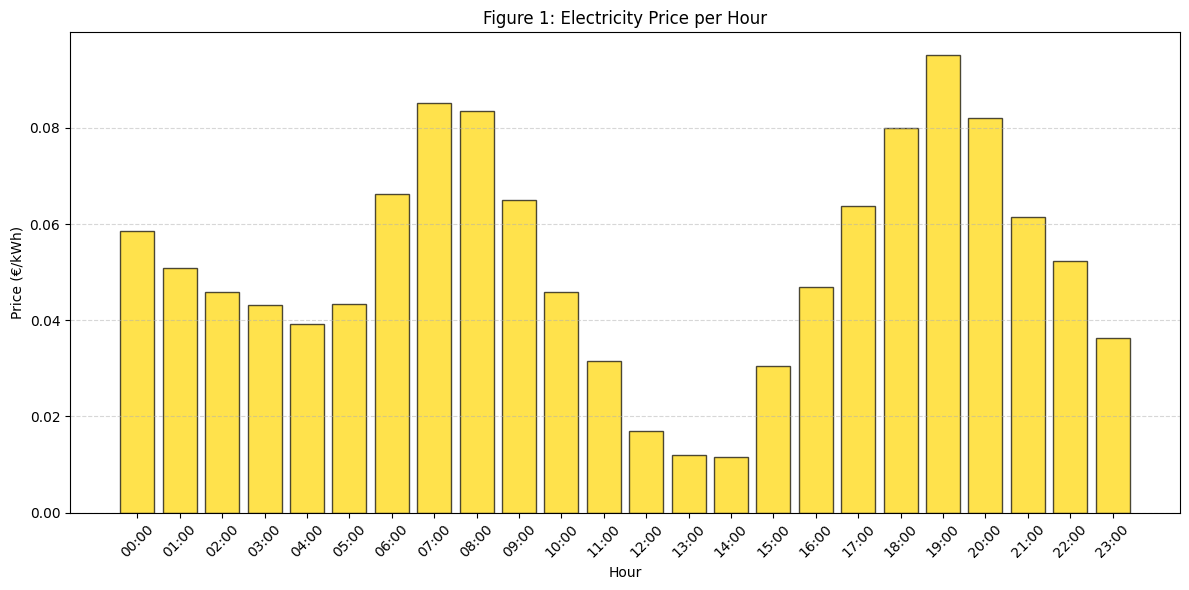

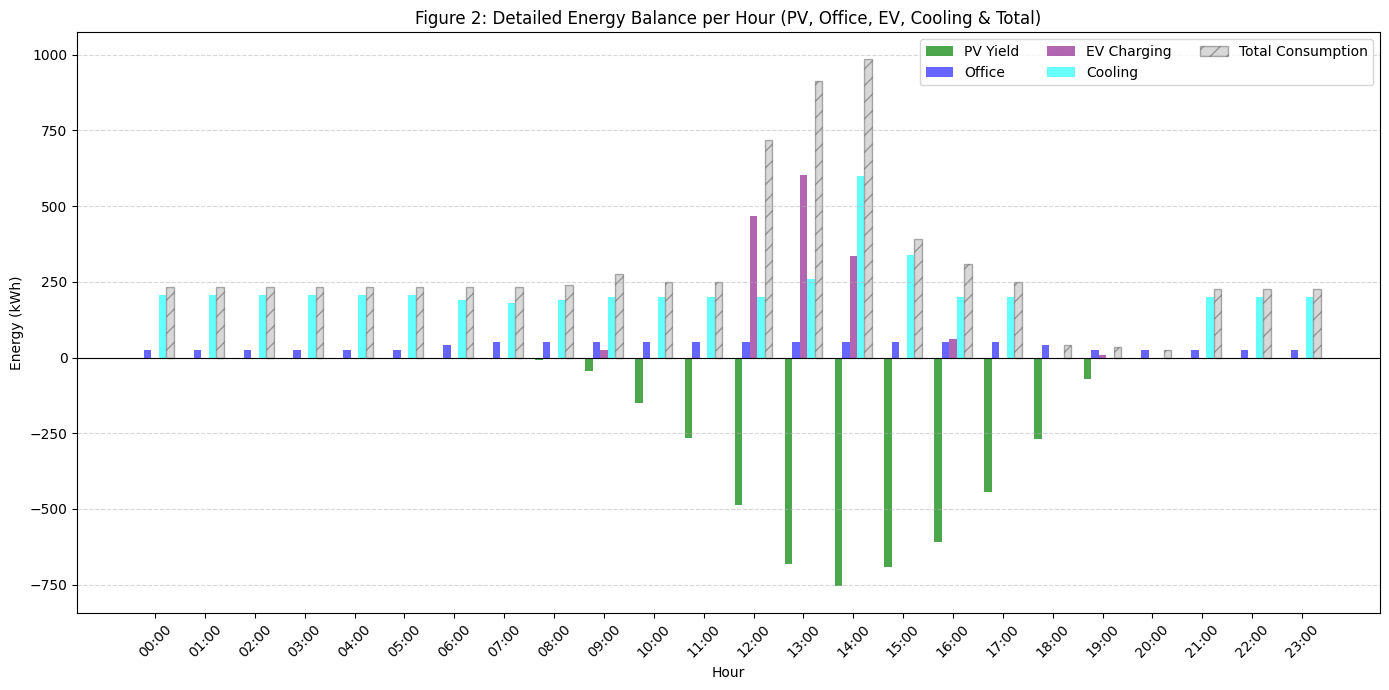

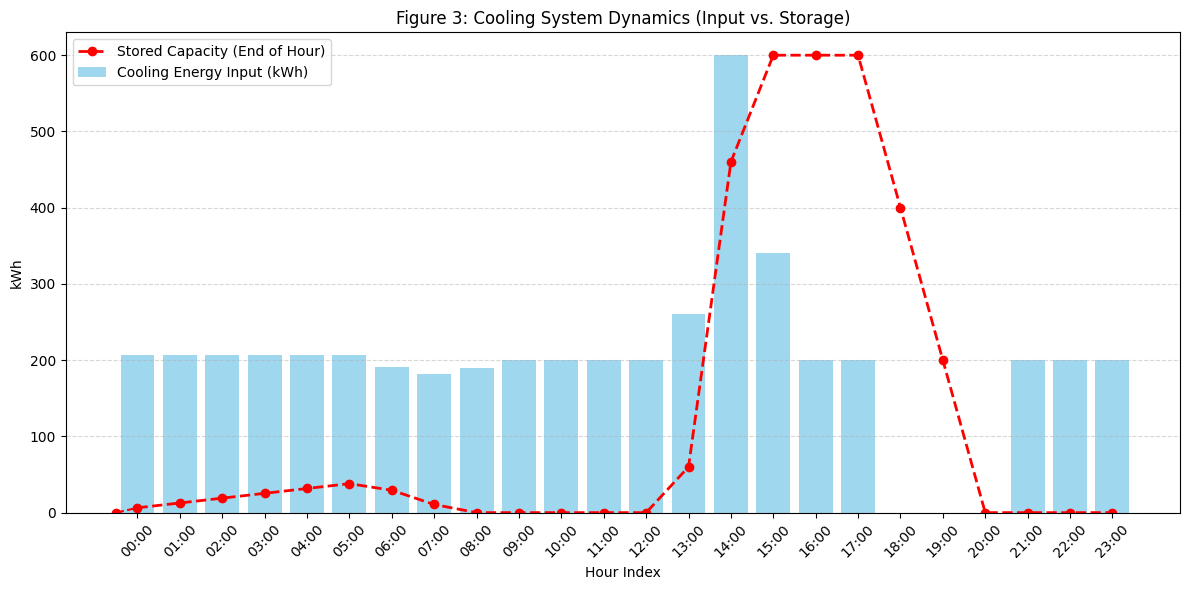

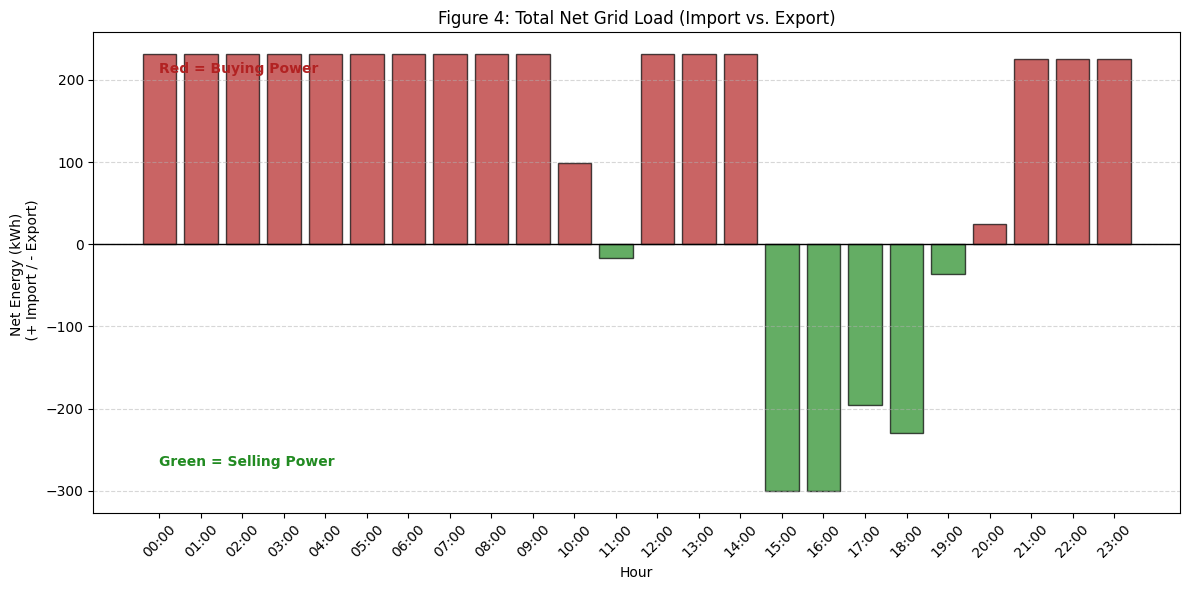

In [78]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np  # Needed for positioning the side-by-side bars

# --- 1. PREPARE DATA ---
# We calculate the lists first to easily compute the Total Load
pv_neg = [-pv_yield[t] for t in hours]
office = [office_usage[t] for t in hours]
cooling = [cooling_input[t].X for t in hours]
ev = [ev_charge[t].X for t in hours]
grid = [grid_net[t].X for t in hours]
price = [price_per_kwh[t] for t in hours]

# Calculate Total Consumption (Office + Cooling + EV)
total_load = [o + c + e for o, c, e in zip(office, cooling, ev)]

plot_data = {
    "Hour": hours,
    "Price": price,
    "PV_Yield_Neg": pv_neg,
    "Office_Usage": office,
    "Cooling_Input": cooling,
    "EV_Charge": ev,          # Added EV
    "Total_Load": total_load, # Added Total
    "Grid_Net": grid
}

# For the storage line logic
storage_values = [cooling_storage[t].X for t in hours]
storage_plot_values = [0] + storage_values 
storage_plot_time = [-0.5] + list(range(len(hours)))

df_plot = pd.DataFrame(plot_data)

# --- FIGURE 1: Prices per Hour ---
plt.figure(figsize=(12, 6))
plt.bar(df_plot["Hour"], df_plot["Price"], color='gold', edgecolor='black', alpha=0.7)
plt.title("Figure 1: Electricity Price per Hour")
plt.ylabel("Price (€/kWh)")
plt.xlabel("Hour")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- FIGURE 2: Detailed Energy Balance (Side-by-Side) ---
# UPDATED: Now includes EV and Total Load in a grouped bar chart
plt.figure(figsize=(14, 7))

# X-axis setup
x = np.arange(len(hours)) 
width = 0.15  # Width of the bars

# Plotting the bars side-by-side
# 1. PV Yield (Green, Negative)
plt.bar(x - 2*width, df_plot["PV_Yield_Neg"], width, label='PV Yield', color='green', alpha=0.7)
# 2. Office Usage (Blue)
plt.bar(x - 1*width, df_plot["Office_Usage"], width, label='Office', color='blue', alpha=0.6)
# 3. EV Charging (Purple)
plt.bar(x,           df_plot["EV_Charge"],    width, label='EV Charging', color='purple', alpha=0.6)
# 4. Cooling Usage (Cyan)
plt.bar(x + 1*width, df_plot["Cooling_Input"], width, label='Cooling', color='cyan', alpha=0.6)
# 5. Total Consumption (Gray, Hatched)
plt.bar(x + 2*width, df_plot["Total_Load"],    width, label='Total Consumption', color='gray', alpha=0.3, hatch='//', edgecolor='black')

plt.axhline(0, color='black', linewidth=0.8)
plt.title("Figure 2: Detailed Energy Balance per Hour (PV, Office, EV, Cooling & Total)")
plt.ylabel("Energy (kWh)")
plt.xlabel("Hour")
plt.xticks(x, hours, rotation=45)
plt.legend(loc="upper right", ncol=3) # Spread legend over 3 columns
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- FIGURE 3: Cooling Usage & Storage (With 0-Start Offset) ---
plt.figure(figsize=(12, 6))
plt.bar(df_plot["Hour"], df_plot["Cooling_Input"], color='skyblue', label='Cooling Energy Input (kWh)', alpha=0.8)

# Line chart for storage
plt.plot(storage_plot_time[1:], storage_values, color='red', linestyle='--', marker='o', linewidth=2, label='Stored Capacity (End of Hour)')
# Visual start point
plt.plot(-0.5, 0, marker='o', color='red') 
plt.plot([-0.5, 0], [0, storage_values[0]], color='red', linestyle='--') 

plt.title("Figure 3: Cooling System Dynamics (Input vs. Storage)")
plt.ylabel("kWh")
plt.xlabel("Hour Index")
plt.xticks(ticks=range(24), labels=hours, rotation=45)
plt.legend(loc="upper left")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- FIGURE 4: Total Net Grid Load ---
plt.figure(figsize=(12, 6))
colors = ['firebrick' if x >= 0 else 'forestgreen' for x in df_plot["Grid_Net"]]

plt.bar(df_plot["Hour"], df_plot["Grid_Net"], color=colors, edgecolor='black', alpha=0.7)
plt.axhline(0, color='black', linewidth=1)

plt.title("Figure 4: Total Net Grid Load (Import vs. Export)")
plt.ylabel("Net Energy (kWh) \n (+ Import / - Export)")
plt.xlabel("Hour")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.text(0, max(df_plot["Grid_Net"])*0.9, "Red = Buying Power", color='firebrick', fontweight='bold')
plt.text(0, min(df_plot["Grid_Net"])*0.9, "Green = Selling Power", color='forestgreen', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
cost_diff = total_cost2- total_cost

print(f"In order to save money €{cost_diff} a day needs to be saved over a power usage of {total_power}kwh")
print(f"so the cost per kwh should drop with {cost_diff/total_power}")

In order to save money €17.351193333333413 a day needs to be saved over a power usage of 2728.0000000000005
so the cost per kwh should drop with 0.0063604081133920125
